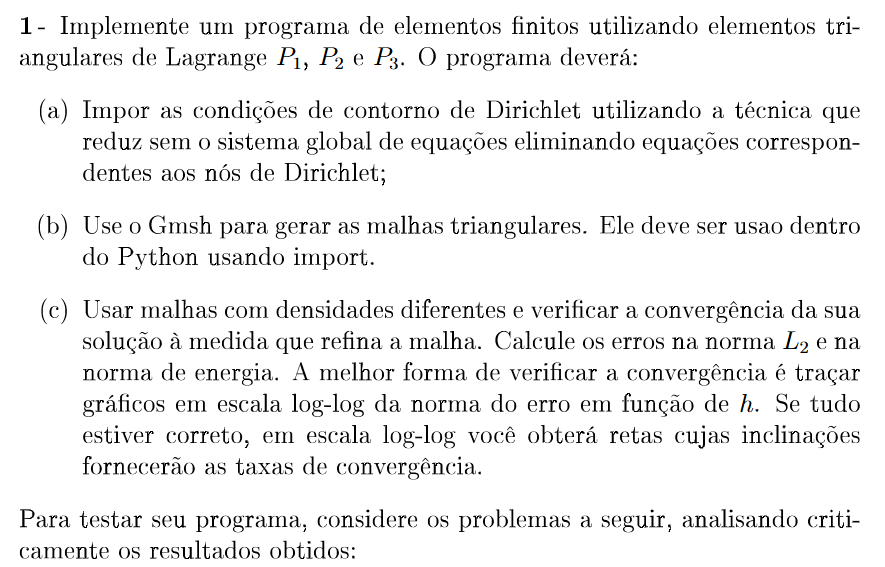

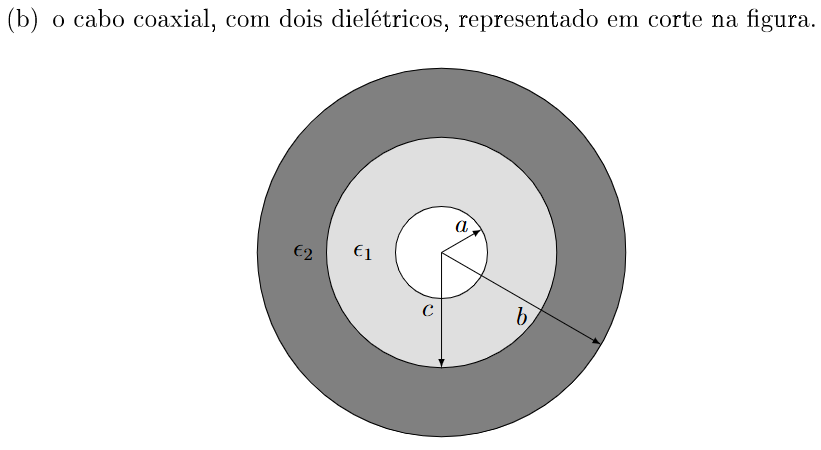
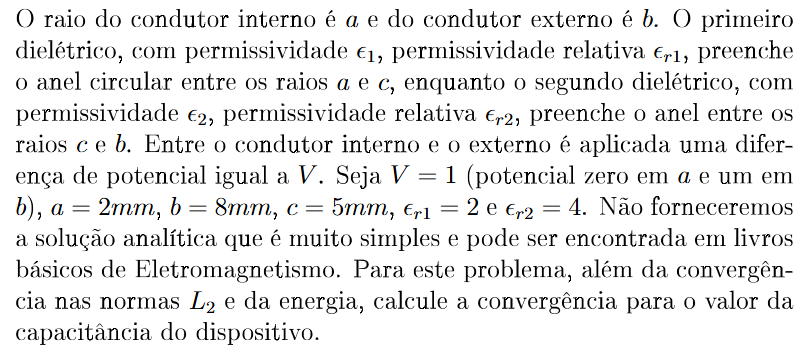

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve

from main.mesh import coax_mesh2D
from main.engine import assemble_coax_system

from main.boundary_conditions import apply_dirichlet_coax
from main.l2_error import l2_error_coaxi, exact_coaxial

p_values = [1,2,3]
lc_values = [1.0e-3,5.0e-4,2.5e-4,1.25e-4]

for p in p_values:
    print('Ordem p =',p)
    erros = []
    for lc in lc_values:

        malha = coax_mesh2D(lc=lc,a=0.02,c=0.005,b=0.008,p=p,show_mesh=False)


        K, F = assemble_coax_system(malha.nodes,malha.triangles,malha.element_material,p)

        Kff, Ff, free_dofs = apply_dirichlet_coax(K,F,malha.dirichlet_dofs,malha.dirichlet_values)

        u_free = spsolve(csr_matrix(Kff),Ff)
        
        u = np.zeros(len(F))
        u[malha.dirichlet_dofs] = malha.dirichlet_values
        u[free_dofs] = u_free

        x = malha.nodes[:, 0]
        y = malha.nodes[:, 1]

        u_exact = exact_coaxial(x, y)

        error_l2 = l2_error_coaxi(malha,u,p,u_exact)
        erros.append(error_l2)
                
        if len(erros) >= 2:
            rate = np.log(erros[-2] / erros[-1]) / np.log(2)
            print(f"lc = {lc} ==> Norma L2 do erro = {error_l2:1.2e} ==> Taxa de convergência = {rate:.2f}")
        else: print(f"lc = {lc} ==> Norma L2 do erro = {error_l2:1.2e}")

        eps0 = 8.8541878128e-12

        C_numeric = (eps0 * (u @ (K @ u)))
        #print(f"C' = {(C_numeric * 1e12):.2f} pF/m ===> Valor esperado : 96.64 (CONFERIR) pF/m")

    x_reta = np.linspace(np.min(np.log(lc_values)),np.max(np.log(lc_values)),100)
    b = np.log(erros[-1])
    a = [2,3,4]

    y_reta = a[p-1]*(x_reta - np.min(np.log(lc_values))) + b
    
    plt.figure()
    plt.title(f'Convergência Espacial - p = {p}')
    plt.grid(alpha=0.3)
    plt.plot(x_reta,y_reta,ls='--',color='black')
    plt.scatter(np.log(lc_values),np.log(erros),color='red')
    plt.ylabel(r'$||u - u_h||_{L^2}$ (log)')
    plt.xlabel('Tamanho característico do elemento (log)')
    plt.show()

triang = mtri.Triangulation(x,y,malha.triangles[:, :3])
plt.figure()
plt.tricontourf(triang,u,levels=30)
plt.colorbar(label="u")
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Potencial eletrostático - MEF - lc = {lc} - p = {p}")
plt.show()

plt.figure()
plt.tricontourf(triang,u_exact,levels=30)
plt.colorbar(label="u")
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Potencial eletrostático - Analítico")
plt.show()

Ordem p = 1


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()